In [46]:
import pandas as pd
import numpy as np
#visual
import matplotlib.pyplot as plt
import sklearn
#sklear
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

# Column names (official description)
columns = [
    "checking_status", "duration", "credit_history", "purpose",
    "credit_amount", "savings_status", "employment",
    "installment_commitment", "personal_status", "other_parties",
    "residence_since", "property_magnitude", "age",
    "other_payment_plans", "housing", "existing_credits",
    "job", "num_dependents", "own_telephone", "foreign_worker",
    "target"
]
df = pd.read_csv(url, sep=" ", header=None)
df.columns = columns

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
print("Shape:", df.shape)

Shape: (1000, 21)


In [5]:
df["target"] = df["target"].map({1: 0, 2: 1})

df["target"].value_counts()

target
0    700
1    300
Name: count, dtype: int64

## 2

In [6]:
df.isnull().sum()

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
target                    0
dtype: int64

In [7]:
df.dtypes

checking_status             str
duration                  int64
credit_history              str
purpose                     str
credit_amount             int64
savings_status              str
employment                  str
installment_commitment    int64
personal_status             str
other_parties               str
residence_since           int64
property_magnitude          str
age                       int64
other_payment_plans         str
housing                     str
existing_credits          int64
job                         str
num_dependents            int64
own_telephone               str
foreign_worker              str
target                    int64
dtype: object

In [11]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "str"]).columns.tolist()
numeric_features.remove("target")
print("Numeric features:")
print(numeric_features)
print("Numeric:", len(numeric_features))

print("\nCategorical features:")
print(categorical_features)
print("Categorical:", len(categorical_features))


Numeric features:
['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Numeric: 7

Categorical features:
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Categorical: 13


In [13]:
corr_matrix = df[numeric_features + ["target"]].corr()

corr_matrix

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,target
duration,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834,0.214927
credit_amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142,0.154739
installment_commitment,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207,0.072404
residence_since,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643,0.002967
age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201,-0.091127
existing_credits,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667,-0.045732
num_dependents,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000,-0.003015
target,0.214927,0.154739,0.072404,0.002967,-0.091127,-0.045732,-0.003015,1.000000


In [14]:
corr_with_target = corr_matrix["target"].sort_values(ascending=False)

corr_with_target

target                    1.000000
duration                  0.214927
credit_amount             0.154739
installment_commitment    0.072404
residence_since           0.002967
num_dependents           -0.003015
existing_credits         -0.045732
age                      -0.091127
Name: target, dtype: float64

In [16]:
top3 = corr_with_target.drop("target").head(3)
top3

duration                  0.214927
credit_amount             0.154739
installment_commitment    0.072404
Name: target, dtype: float64

## 3

In [31]:
x = df.drop("target", axis=1)
y = df["target"]

In [32]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (800, 20)
Test shape: (200, 20)


In [33]:
numeric_features = x_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = x_train.select_dtypes(include=["object","str"]).columns.tolist()

In [34]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")
# categorical_transformer.shape

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        # ( "Nickname", Tool_to_use, List_of_columns )
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [42]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])
log_model.fit(x_train, y_train)
    

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [43]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])
tree_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [44]:
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])
knn_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [45]:
def evaluate_model(model, x_test, y_test, name):
    y_pred = model.predict(x_test)

    print(f"\n{name}")
    print("-" * 30)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)
    print("Confusion Matrix:\n:", cm)

    return acc, prec, rec, f1, cm

In [48]:
log_results = evaluate_model(log_model, x_test, y_test, "Logistic Regression")
tree_results = evaluate_model(tree_model, x_test, y_test, "Decision Tree")
knn_results = evaluate_model(knn_model, x_test, y_test, "kNN")


Logistic Regression
------------------------------
Accuracy: 0.78
Precision: 0.6666666666666666
Recall: 0.5333333333333333
F1-score: 0.5925925925925926
Confusion Matrix:
: [[124  16]
 [ 28  32]]

Decision Tree
------------------------------
Accuracy: 0.63
Precision: 0.3793103448275862
Recall: 0.36666666666666664
F1-score: 0.3728813559322034
Confusion Matrix:
: [[104  36]
 [ 38  22]]

kNN
------------------------------
Accuracy: 0.725
Precision: 0.5675675675675675
Recall: 0.35
F1-score: 0.4329896907216495
Confusion Matrix:
: [[124  16]
 [ 39  21]]


## 5

In [50]:
y_probs = log_model.predict_proba(x_test)[:, 1]

In [60]:
def evaluate_threshold(y_test, y_probs, threshold):
    y_pred = (y_probs >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\nThreshold: {threshold}")
    print("-" * 30)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("Confusion Matrix:\n", cm)

    return cm

In [61]:
cm_65 = evaluate_threshold(y_test, y_probs, 0.65)


Threshold: 0.65
------------------------------
Accuracy: 0.775
Precision: 0.7586206896551724
Recall: 0.36666666666666664
F1: 0.4943820224719101
Confusion Matrix:
 [[133   7]
 [ 38  22]]


In [62]:
cm_50 = evaluate_threshold(y_test, y_probs, 0.50)


Threshold: 0.5
------------------------------
Accuracy: 0.78
Precision: 0.6666666666666666
Recall: 0.5333333333333333
F1: 0.5925925925925926
Confusion Matrix:
 [[124  16]
 [ 28  32]]


In [63]:
cm_35 = evaluate_threshold(y_test, y_probs, 0.35)


Threshold: 0.35
------------------------------
Accuracy: 0.775
Precision: 0.5974025974025974
Recall: 0.7666666666666667
F1: 0.6715328467153284
Confusion Matrix:
 [[109  31]
 [ 14  46]]


## 6

In [64]:
y_probs = log_model.predict_proba(x_test)[:,1]

In [67]:
def assign_zone(p):
    if p < 0.20:
        return "Auto-Approve"
    elif p <= 0.50:
        return "Manual Review"
    else:
        return "Auto Reject"

zones = pd.Series(y_probs).apply(assign_zone)

In [68]:
zone_counts = zones.value_counts()
zone_counts

Auto-Approve     91
Manual Review    61
Auto Reject      48
Name: count, dtype: int64

## 7

In [73]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "kNN"],
    "Accuracy": [log_results[0], tree_results[0], knn_results[0]],
    "Recall (Bad)": [log_results[2], tree_results[2], knn_results[2]],
    "F1 Score": [log_results[3], tree_results[3], knn_results[3]],
    "Comment": [
        "Balanced and stable",
        "High variance, risk of overfitting",
        "Sensitive to scaling of neighbors"
    ]
})
comparison

,Model,Accuracy,Recall (Bad),F1 Score,Comment
0,Logistic Regression,0.780,0.533333,0.592593,Balanced and stable
1,Decision Tree,0.630,0.366667,0.372881,"High variance, risk of overfitting"
2,kNN,0.725,0.350000,0.432990,Sensitive to scaling of neighbors


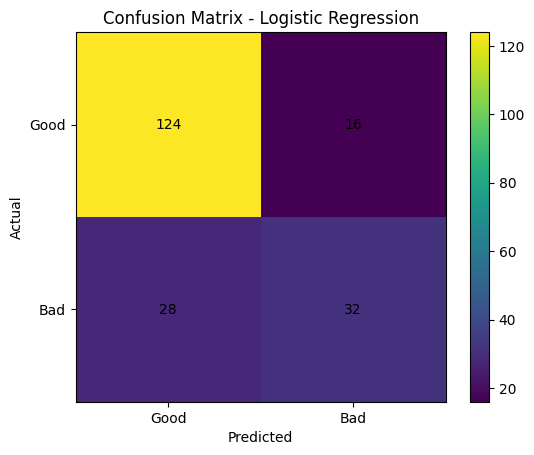

In [75]:
cm = log_results[4]

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
plt.xticks([0, 1], ["Good", "Bad"])
plt.yticks([0, 1], ["Good", "Bad"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [ ]:
sample_probs = y_probs[:3]